<a href="https://colab.research.google.com/github/ecem-gunes/House_Price_Prediction_and_Clustering/blob/main/House_Price_Prediction_and_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A-1: Veri Yükleme

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

path_train = '/content/drive/MyDrive/Machine_learning_Midterm/midtermProject-part1-train.xlsx'
path_test = '/content/drive/MyDrive/Machine_learning_Midterm/midtermProject-part1-test.xlsx'
path_part2 = '/content/drive/MyDrive/Machine_learning_Midterm/midtermProject-part2-data.xlsx'

# Verileri Okuma
train_df = pd.read_excel(path_train)
test_df = pd.read_excel(path_test)
part2_df = pd.read_excel(path_part2)

print("Tüm veri setleri başarıyla yüklendi.\n")

# --- VERİ TEYİT (İlk 5 Satır) ---
print("-" * 30)
print("PART A: TRAIN DATA (İlk 5 Satır)")
display(train_df.head())

print("\n" + "-" * 30)
print("PART A: TEST DATA (İlk 5 Satır)")
display(test_df.head())

print("\n" + "-" * 30)
print("PART B: CLUSTERING DATA (İlk 5 Satır)")
display(part2_df.head())

print("Tüm veri setleri başarıyla yüklendi.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Tüm veri setleri başarıyla yüklendi.

------------------------------
PART A: TRAIN DATA (İlk 5 Satır)


,Neighborhood,Age (Years),Net Square Meters (m2),Price (TRY)
0,1,13,140,8950000
1,1,18,150,17750000
2,1,13,150,17250000
3,1,13,140,16500000
4,1,18,160,15380000



------------------------------
PART A: TEST DATA (İlk 5 Satır)


,Neighborhood,Age (Years),Net Square Meters (m2),Price (TRY)
0,1,8.0,120,13750000
1,1,18.0,140,9100000
2,1,18.0,130,7600000
3,1,0.0,95,11650000
4,1,13.0,150,17500000



------------------------------
PART B: CLUSTERING DATA (İlk 5 Satır)


,Başçevre,Boy,Kilo
0,48.211372,96.959801,14.195565
1,39.627819,60.037124,5.266901
2,42.902915,64.686372,7.373345
3,48.600000,80.600000,11.800000
4,44.800000,67.600000,8.400000


Tüm veri setleri başarıyla yüklendi.


A-2: Normalizasyon (Min-Max)

In [2]:
# --- Mahalle: kategorik — train sütunlarına hizalı one-hot (testte yeni kod varsa 0) ---
neigh_train = pd.get_dummies(train_df['Neighborhood'].astype(str), prefix='N')
neigh_test  = pd.get_dummies(test_df['Neighborhood'].astype(str), prefix='N')
neigh_test  = neigh_test.reindex(columns=neigh_train.columns, fill_value=0)

age_train = train_df[['Age (Years)']].values.astype(float)
sqm_train = train_df[['Net Square Meters (m2)']].values.astype(float)
age_test  = test_df[['Age (Years)']].values.astype(float)
sqm_test  = test_df[['Net Square Meters (m2)']].values.astype(float)

age_min, age_max = age_train.min(axis=0), age_train.max(axis=0)
sqm_min, sqm_max = sqm_train.min(axis=0), sqm_train.max(axis=0)

def minmax_normalize(data, d_min, d_max):
    return (data - d_min) / (d_max - d_min)

age_train_n = minmax_normalize(age_train, age_min, age_max)
sqm_train_n = minmax_normalize(sqm_train, sqm_min, sqm_max)
age_test_n  = minmax_normalize(age_test,  age_min, age_max)
sqm_test_n  = minmax_normalize(sqm_test,  sqm_min, sqm_max)

X_train = np.hstack([neigh_train.values.astype(float), age_train_n, sqm_train_n])
X_test  = np.hstack([neigh_test.values.astype(float),  age_test_n,  sqm_test_n])

y_train = train_df[['Price (TRY)']].values.astype(float)
y_test  = test_df[['Price (TRY)']].values.astype(float)

y_min = y_train.min()
y_max = y_train.max()

y_train_norm = minmax_normalize(y_train, y_min, y_max)
y_test_norm  = minmax_normalize(y_test,  y_min, y_max)

def minmax_denormalize(data_norm, d_min, d_max):
    return data_norm * (d_max - d_min) + d_min

INPUT_SIZE = X_train.shape[1]
print(f"Özellik boyutu (one-hot + 2 sayısal): {INPUT_SIZE}")
print("Normalizasyon tamamlandı.")

Özellik boyutu (one-hot + 2 sayısal): 6
Normalizasyon tamamlandı.


Part A-3 : MLP Mimarisi

Epoch 500/5000 — Avg MSE (norm): 0.003405
Epoch 1000/5000 — Avg MSE (norm): 0.003212
Epoch 1500/5000 — Avg MSE (norm): 0.003140
Epoch 2000/5000 — Avg MSE (norm): 0.003001
Epoch 2500/5000 — Avg MSE (norm): 0.002917
Epoch 3000/5000 — Avg MSE (norm): 0.002900
Epoch 3500/5000 — Avg MSE (norm): 0.003090
Epoch 4000/5000 — Avg MSE (norm): 0.002912
Epoch 4500/5000 — Avg MSE (norm): 0.002818
Epoch 5000/5000 — Avg MSE (norm): 0.002825

Eğitim tamamlandı.


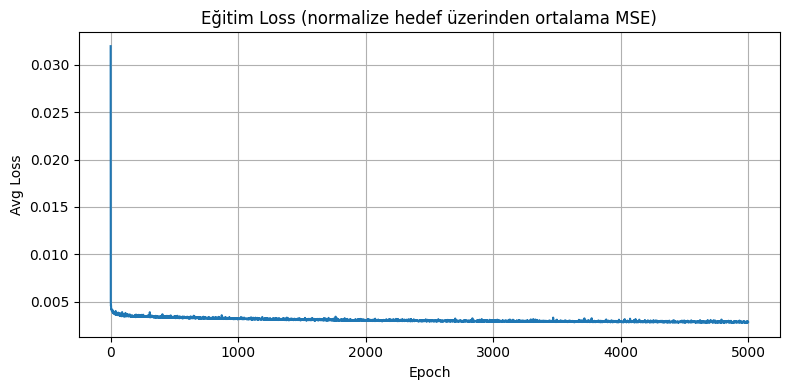

In [5]:
np.random.seed(42)

HIDDEN1_SIZE  = 32
HIDDEN2_SIZE  = 16
OUTPUT_SIZE   = 1
LEARNING_RATE = 0.01
MOMENTUM      = 0.9
EPOCHS        = 5000
BATCH_SIZE    = 16

def relu(z):
    return np.maximum(0.0, z)

def relu_deriv(z):
    return (z > 0.0).astype(np.float64)

def he_init(fan_in, fan_out):
    return np.random.randn(fan_in, fan_out) * np.sqrt(2.0 / fan_in)

W1 = he_init(INPUT_SIZE, HIDDEN1_SIZE)
b1 = np.zeros((1, HIDDEN1_SIZE))
W2 = he_init(HIDDEN1_SIZE, HIDDEN2_SIZE)
b2 = np.zeros((1, HIDDEN2_SIZE))
W3 = he_init(HIDDEN2_SIZE, OUTPUT_SIZE)
b3 = np.zeros((1, OUTPUT_SIZE))

dW1_prev = np.zeros_like(W1); db1_prev = np.zeros_like(b1)
dW2_prev = np.zeros_like(W2); db2_prev = np.zeros_like(b2)
dW3_prev = np.zeros_like(W3); db3_prev = np.zeros_like(b3)

def forward(X):
    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    A2 = relu(Z2)
    Z3 = A2 @ W3 + b3   # lineer çıkış (regresyon)
    return Z1, A1, Z2, A2, Z3

loss_history = []
n_samples = len(X_train)
indices = np.arange(n_samples)

for epoch in range(EPOCHS):
    np.random.shuffle(indices)
    total_loss = 0.0
    num_batches = 0

    for start in range(0, n_samples, BATCH_SIZE):
        batch_idx = indices[start:start + BATCH_SIZE]
        X_b = X_train[batch_idx]
        y_b = y_train_norm[batch_idx]
        B = X_b.shape[0]

        Z1, A1, Z2, A2, Z3 = forward(X_b)

        err = Z3 - y_b
        total_loss += 0.5 * np.sum(err ** 2)
        num_batches += 1

        delta3 = err / B
        delta2 = (delta3 @ W3.T) * relu_deriv(Z2)
        delta1 = (delta2 @ W2.T) * relu_deriv(Z1)

        dW3 = A2.T @ delta3
        db3 = np.sum(delta3, axis=0, keepdims=True)
        dW2 = A1.T @ delta2
        db2 = np.sum(delta2, axis=0, keepdims=True)
        dW1 = X_b.T @ delta1
        db1 = np.sum(delta1, axis=0, keepdims=True)

        dW1_prev = MOMENTUM * dW1_prev + LEARNING_RATE * dW1; W1 -= dW1_prev
        dW2_prev = MOMENTUM * dW2_prev + LEARNING_RATE * dW2; W2 -= dW2_prev
        dW3_prev = MOMENTUM * dW3_prev + LEARNING_RATE * dW3; W3 -= dW3_prev
        db1_prev = MOMENTUM * db1_prev + LEARNING_RATE * db1; b1 -= db1_prev
        db2_prev = MOMENTUM * db2_prev + LEARNING_RATE * db2; b2 -= db2_prev
        db3_prev = MOMENTUM * db3_prev + LEARNING_RATE * db3; b3 -= db3_prev

    avg_loss = total_loss / n_samples
    loss_history.append(avg_loss)
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} — Avg MSE (norm): {avg_loss:.6f}")

print("\nEğitim tamamlandı.")

plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.title("Eğitim Loss (normalize hedef üzerinden ortalama MSE)")
plt.xlabel("Epoch")
plt.ylabel("Avg Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

A-4: Performans Metrikleri

In [7]:
def predict(X):
    _, _, _, _, Z3 = forward(X)
    return Z3

y_train_pred_norm = predict(X_train)
y_test_pred_norm  = predict(X_test)

# Tahminler [0,1] dışına çıkabilir (lineer çıkış); denormalize önce kırpma isteğe bağlı:
# y_train_pred_norm = np.clip(y_train_pred_norm, 0.0, 1.0)

y_train_pred = minmax_denormalize(y_train_pred_norm, y_min, y_max)
y_test_pred  = minmax_denormalize(y_test_pred_norm,  y_min, y_max)
y_train_real = minmax_denormalize(y_train_norm, y_min, y_max)
y_test_real  = minmax_denormalize(y_test_norm,  y_min, y_max)

def calc_mae(y_real, y_pred):
    return np.mean(np.abs(y_real - y_pred))

def calc_mse(y_real, y_pred):
    return np.mean((y_real - y_pred) ** 2)

def calc_rmse(y_real, y_pred):
    return np.sqrt(calc_mse(y_real, y_pred))

def calc_r2(y_real, y_pred):
    ss_res = np.sum((y_real - y_pred) ** 2)
    ss_tot = np.sum((y_real - np.mean(y_real)) ** 2)
    return 1 - (ss_res / ss_tot)

train_mae  = calc_mae(y_train_real,  y_train_pred)
train_mse  = calc_mse(y_train_real,  y_train_pred)
train_rmse = calc_rmse(y_train_real, y_train_pred)
train_r2   = calc_r2(y_train_real,   y_train_pred)

test_mae  = calc_mae(y_test_real,  y_test_pred)
test_mse  = calc_mse(y_test_real,  y_test_pred)
test_rmse = calc_rmse(y_test_real, y_test_pred)
test_r2   = calc_r2(y_test_real,   y_test_pred)

print("=" * 45)
print("TRAIN RESULTS")
print(f"  MAE  : {train_mae:,.2f} TRY")
print(f"  MSE  : {train_mse:,.2f} TRY²")
print(f"  RMSE : {train_rmse:,.2f} TRY")
print(f"  R²   : {train_r2:.6f}")
print("\nTEST RESULTS")
print(f"  MAE  : {test_mae:,.2f} TRY")
print(f"  MSE  : {test_mse:,.2f} TRY²")
print(f"  RMSE : {test_rmse:,.2f} TRY")
print(f"  R²   : {test_r2:.6f}")
print("=" * 45)

TRAIN RESULTS
  MAE  : 2,341,940.57 TRY
  MSE  : 12,840,278,093,949.82 TRY²
  RMSE : 3,583,333.38 TRY
  R²   : 0.489948

TEST RESULTS
  MAE  : 2,923,340.57 TRY
  MSE  : 22,627,234,098,781.53 TRY²
  RMSE : 4,756,809.24 TRY
  R²   : 0.310944


A-5: Rapor Üretimi

In [8]:
### Hücre A-5: Rapor Üretimi (report.txt) ###

report_lines = []

report_lines.append("=" * 60)
report_lines.append("PART A — MLP REGRESYON RAPORU")
report_lines.append("=" * 60)

# ─── ANN PARAMETRELERİ ───────────────────────────────────────────
report_lines.append("\n--- ANN PARAMETRELERİ ---")
report_lines.append(f"Girdi boyutu       : {INPUT_SIZE} (4 one-hot Neighborhood + Age + m²)")
report_lines.append(f"Gizli katman 1     : {HIDDEN1_SIZE} nöron — ReLU aktivasyonu")
report_lines.append(f"Gizli katman 2     : {HIDDEN2_SIZE} nöron — ReLU aktivasyonu")
report_lines.append(f"Çıkış katmanı      : {OUTPUT_SIZE} nöron — Linear (aktivasyon yok)")
report_lines.append(f"Başlangıç LR       : {LEARNING_RATE}")
report_lines.append(f"Momentum           : {MOMENTUM}")
report_lines.append(f"Epoch sayısı       : {EPOCHS}")
report_lines.append(f"Batch size         : {BATCH_SIZE}")
report_lines.append(f"Eğitim bitiş koşulu: {EPOCHS} epoch tamamlanması")
report_lines.append(f"Weight init        : He initialization (sqrt(2/fan_in))")
report_lines.append(f"Normalizasyon      : Min-Max (train istatistikleri ile)")

# ─── PERFORMANS METRİKLERİ ───────────────────────────────────────
report_lines.append("\n--- PERFORMANS METRİKLERİ ---")
report_lines.append("Train Results:")
report_lines.append(f"  MAE  : {train_mae:,.2f} TRY")
report_lines.append(f"  MSE  : {train_mse:,.2f} TRY²")
report_lines.append(f"  RMSE : {train_rmse:,.2f} TRY")
report_lines.append(f"  R²   : {train_r2:.6f}")
report_lines.append("Test Results:")
report_lines.append(f"  MAE  : {test_mae:,.2f} TRY")
report_lines.append(f"  MSE  : {test_mse:,.2f} TRY²")
report_lines.append(f"  RMSE : {test_rmse:,.2f} TRY")
report_lines.append(f"  R²   : {test_r2:.6f}")

# ─── FINAL WEIGHT & BIAS DEĞERLERİ ──────────────────────────────
report_lines.append("\n--- FINAL WEIGHT & BIAS DEĞERLERİ ---")

report_lines.append("\nW1 (Input→Hidden1):")
report_lines.append(np.array2string(W1, precision=6, suppress_small=True))
report_lines.append("\nb1 (Hidden1 bias):")
report_lines.append(np.array2string(b1, precision=6, suppress_small=True))

report_lines.append("\nW2 (Hidden1→Hidden2):")
report_lines.append(np.array2string(W2, precision=6, suppress_small=True))
report_lines.append("\nb2 (Hidden2 bias):")
report_lines.append(np.array2string(b2, precision=6, suppress_small=True))

report_lines.append("\nW3 (Hidden2→Output):")
report_lines.append(np.array2string(W3, precision=6, suppress_small=True))
report_lines.append("\nb3 (Output bias):")
report_lines.append(np.array2string(b3, precision=6, suppress_small=True))

report_lines.append("\n" + "=" * 60)

# ─── DOSYAYA YAZ ─────────────────────────────────────────────────
report_text = "\n".join(report_lines)

report_path = '/content/drive/MyDrive/Machine_learning_Midterm/report.txt'
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(report_text)

print(report_text)
print(f"\nRapor kaydedildi: {report_path}")

PART A — MLP REGRESYON RAPORU

--- ANN PARAMETRELERİ ---
Girdi boyutu       : 6 (4 one-hot Neighborhood + Age + m²)
Gizli katman 1     : 32 nöron — ReLU aktivasyonu
Gizli katman 2     : 16 nöron — ReLU aktivasyonu
Çıkış katmanı      : 1 nöron — Linear (aktivasyon yok)
Başlangıç LR       : 0.01
Momentum           : 0.9
Epoch sayısı       : 5000
Batch size         : 16
Eğitim bitiş koşulu: 5000 epoch tamamlanması
Weight init        : He initialization (sqrt(2/fan_in))
Normalizasyon      : Min-Max (train istatistikleri ile)

--- PERFORMANS METRİKLERİ ---
Train Results:
  MAE  : 2,341,940.57 TRY
  MSE  : 12,840,278,093,949.82 TRY²
  RMSE : 3,583,333.38 TRY
  R²   : 0.489948
Test Results:
  MAE  : 2,923,340.57 TRY
  MSE  : 22,627,234,098,781.53 TRY²
  RMSE : 4,756,809.24 TRY
  R²   : 0.310944

--- FINAL WEIGHT & BIAS DEĞERLERİ ---

W1 (Input→Hidden1):
[[ 0.440035  0.124426  0.526297  0.776804 -0.233557 -0.082002  0.840205
   0.218921 -0.271051  0.398441 -0.3      -0.268889  0.135686 -1.1046

Hücre B-1: Part B — Veri Yükleme & Normalizasyon

In [10]:
### Hücre B-1: Part B — Normalizasyon ###

# Veriyi numpy array'e çevir
data = part2_df[['Başçevre', 'Boy', 'Kilo']].values.astype(float)

print("Part B - Clustering Data (İlk 5 Satır):")
display(part2_df.head())
print(f"\nShape: {data.shape}")

# Min-Max normalizasyon (sıfırdan, kütüphane yok)
data_min = data.min(axis=0)
data_max = data.max(axis=0)

def minmax_norm_b(X, X_min, X_max):
    return (X - X_min) / (X_max - X_min)

data_norm = minmax_norm_b(data, data_min, data_max)

print(f"\nNormalize min: {data_norm.min(axis=0).round(4)}")
print(f"Normalize max: {data_norm.max(axis=0).round(4)}")
print("Normalizasyon tamamlandı.")

Part B - Clustering Data (İlk 5 Satır):


,Başçevre,Boy,Kilo
0,48.211372,96.959801,14.195565
1,39.627819,60.037124,5.266901
2,42.902915,64.686372,7.373345
3,48.600000,80.600000,11.800000
4,44.800000,67.600000,8.400000



Shape: (200, 3)

Normalize min: [0. 0. 0.]
Normalize max: [1. 1. 1.]
Normalizasyon tamamlandı.


B-2: K-Means Algoritması

In [13]:
### Hücre B-2: K-Means Algoritması (Sıfırdan — Sadece NumPy) ###

np.random.seed(42)

k = int(input("Küme sayısını girin (k): "))

MAX_ITER = 300

def init_centroids(X, k):
    idx = np.random.choice(len(X), k, replace=False)
    return X[idx].copy()

def euclidean_distances(X, centroids):
    distances = np.zeros((len(X), len(centroids)))
    for j, c in enumerate(centroids):
        distances[:, j] = np.sqrt(np.sum((X - c) ** 2, axis=1))
    return distances

def kmeans(X, k, max_iter=MAX_ITER):
    centroids = init_centroids(X, k)
    labels = np.zeros(len(X), dtype=int)
    for iteration in range(max_iter):
        distances = euclidean_distances(X, centroids)
        new_labels = np.argmin(distances, axis=1)
        if np.all(new_labels == labels) and iteration > 0:
            print(f"Convergence sağlandı: {iteration} iterasyonda.")
            break
        labels = new_labels
        new_centroids = np.zeros_like(centroids)
        for j in range(k):
            cluster_points = X[labels == j]
            if len(cluster_points) > 0:
                new_centroids[j] = cluster_points.mean(axis=0)
            else:
                new_centroids[j] = X[np.random.randint(len(X))]
        centroids = new_centroids
    return labels, centroids

labels, centroids = kmeans(data_norm, k)

print(f"\nk = {k} için sonuçlar:")
for j in range(k):
    count = np.sum(labels == j)
    print(f"  Cluster {j+1}: {count} kayıt")

Küme sayısını girin (k): 3
Convergence sağlandı: 9 iterasyonda.

k = 3 için sonuçlar:
  Cluster 1: 73 kayıt
  Cluster 2: 82 kayıt
  Cluster 3: 45 kayıt


Hücre B-3: WCSS, BCSS, Dunn Index & result.txt

In [14]:
### Hücre B-3: WCSS, BCSS, Dunn Index & result.txt ###

# ─── WCSS (Within Cluster Sum of Squares) ────────────────────────
def calc_wcss(X, labels, centroids, k):
    wcss = 0.0
    for j in range(k):
        cluster_points = X[labels == j]
        if len(cluster_points) > 0:
            wcss += np.sum((cluster_points - centroids[j]) ** 2)
    return wcss

# ─── BCSS (Between Cluster Sum of Squares) ───────────────────────
def calc_bcss(X, labels, centroids, k):
    overall_mean = X.mean(axis=0)
    bcss = 0.0
    for j in range(k):
        n_j = np.sum(labels == j)
        bcss += n_j * np.sum((centroids[j] - overall_mean) ** 2)
    return bcss

# ─── DUNN INDEX ───────────────────────────────────────────────────
def calc_dunn(X, labels, centroids, k):
    # Min cluster-arası mesafe (centroid'ler arası)
    min_inter = np.inf
    for a in range(k):
        for b in range(a + 1, k):
            d = np.sqrt(np.sum((centroids[a] - centroids[b]) ** 2))
            if d < min_inter:
                min_inter = d

    # Max cluster içi çap (en uzak iki nokta arası)
    max_intra = 0.0
    for j in range(k):
        pts = X[labels == j]
        if len(pts) > 1:
            for i in range(len(pts)):
                for l in range(i + 1, len(pts)):
                    d = np.sqrt(np.sum((pts[i] - pts[l]) ** 2))
                    if d > max_intra:
                        max_intra = d

    return min_inter / max_intra if max_intra > 0 else 0.0

# ─── METRİKLERİ HESAPLA ──────────────────────────────────────────
wcss  = calc_wcss(data_norm,  labels, centroids, k)
bcss  = calc_bcss(data_norm,  labels, centroids, k)
dunn  = calc_dunn(data_norm,  labels, centroids, k)

print(f"WCSS      : {wcss:.4f}")
print(f"BCSS      : {bcss:.4f}")
print(f"Dunn Index: {dunn:.4f}")

# ─── RESULT.TXT OLUŞTUR ───────────────────────────────────────────
result_lines = []

for i in range(len(data_norm)):
    result_lines.append(f"Record {i+1}: Cluster {labels[i]+1}")

result_lines.append("")
for j in range(k):
    count = int(np.sum(labels == j))
    result_lines.append(f"Cluster {j+1}: {count} records")

result_lines.append("")
result_lines.append(f"WCSS: {wcss:.4f}")
result_lines.append(f"BCSS: {bcss:.4f}")
result_lines.append(f"Dunn Index: {dunn:.4f}")

result_text = "\n".join(result_lines)

result_path = '/content/drive/MyDrive/Machine_learning_Midterm/result.txt'
with open(result_path, 'w', encoding='utf-8') as f:
    f.write(result_text)

print(f"\nresult.txt kaydedildi: {result_path}")
print("\nİlk 10 satır:")
print("\n".join(result_lines[:10]))

WCSS      : 5.4208
BCSS      : 29.6696
Dunn Index: 0.6906

result.txt kaydedildi: /content/drive/MyDrive/Machine_learning_Midterm/result.txt

İlk 10 satır:
Record 1: Cluster 1
Record 2: Cluster 3
Record 3: Cluster 2
Record 4: Cluster 1
Record 5: Cluster 2
Record 6: Cluster 3
Record 7: Cluster 1
Record 8: Cluster 2
Record 9: Cluster 1
Record 10: Cluster 2


Hücre B-4: Cluster Görselleştirme

Eksen seçimi:
  0: Başçevre
  1: Boy
  2: Kilo
X ekseni (0/1/2): 1
Y ekseni (0/1/2): 2


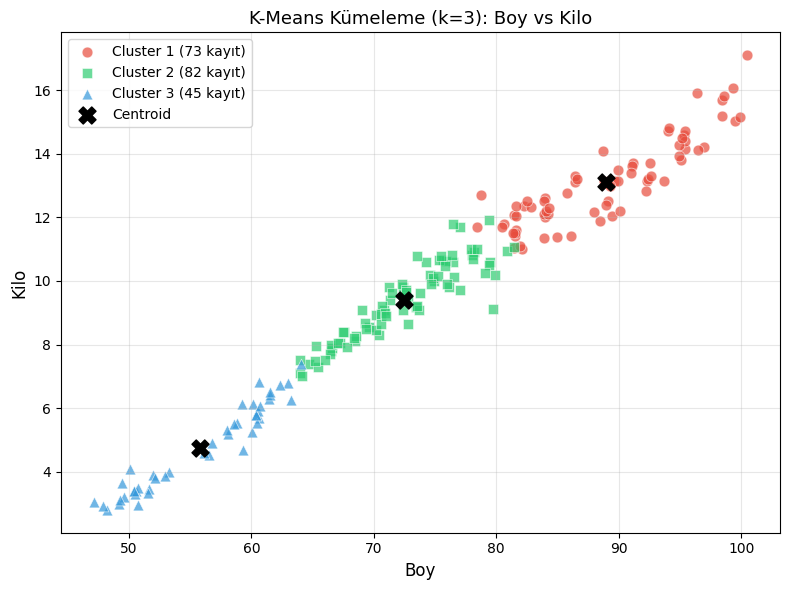

Görsel kaydedildi: /content/drive/MyDrive/Machine_learning_Midterm/cluster_Boy_vs_Kilo.png


In [17]:
### Hücre B-4: Cluster Görselleştirme ###

# Eksen seçim menüsü
col_names = ['Başçevre', 'Boy', 'Kilo']
print("Eksen seçimi:")
print("  0: Başçevre")
print("  1: Boy")
print("  2: Kilo")
x_idx = int(input("X ekseni (0/1/2): "))
y_idx = int(input("Y ekseni (0/1/2): "))

# Renkler ve marker'lar (her cluster farklı)
colors  = ['#E74C3C', '#2ECC71', '#3498DB', '#F39C12', '#9B59B6']
markers = ['o', 's', '^', 'D', 'P']

fig, ax = plt.subplots(figsize=(8, 6))

for j in range(k):
    idx = labels == j
    ax.scatter(
        data[idx, x_idx],
        data[idx, y_idx],
        c=colors[j],
        marker=markers[j],
        label=f'Cluster {j+1} ({np.sum(idx)} kayıt)',
        alpha=0.7,
        edgecolors='white',
        linewidths=0.5,
        s=60
    )

# Centroid'leri gerçek değere çevirerek çiz
centroids_real = centroids * (data_max - data_min) + data_min
ax.scatter(
    centroids_real[:, x_idx],
    centroids_real[:, y_idx],
    c='black',
    marker='X',
    s=150,
    label='Centroid',
    zorder=5
)

ax.set_xlabel(col_names[x_idx], fontsize=12)
ax.set_ylabel(col_names[y_idx], fontsize=12)
ax.set_title(f'K-Means Kümeleme (k={k}): {col_names[x_idx]} vs {col_names[y_idx]}', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

# Kaydet
save_path = f'/content/drive/MyDrive/Machine_learning_Midterm/cluster_{col_names[x_idx]}_vs_{col_names[y_idx]}.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Görsel kaydedildi: {save_path}")

Part A için .py dosyası ddrive a kaydetme

In [20]:
part_a_code = open('/content/drive/MyDrive/Machine_learning_Midterm/partA.py', 'w', encoding='utf-8')
part_a_code.write("""import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount("/content/drive")

# ─── VERİ YÜKLEME ────────────────────────────────────────────────
path_train = "/content/drive/MyDrive/Machine_learning_Midterm/midtermProject-part1-train.xlsx"
path_test  = "/content/drive/MyDrive/Machine_learning_Midterm/midtermProject-part1-test.xlsx"
train_df = pd.read_excel(path_train)
test_df  = pd.read_excel(path_test)
print("Veriler yuklendi.")

# ─── NORMALİZASYON (Neighborhood one-hot, diger min-max) ─────────
def one_hot(col, n_classes):
    result = np.zeros((len(col), n_classes))
    for i, val in enumerate(col):
        result[i, int(val) - 1] = 1.0
    return result

neighborhood_train = one_hot(train_df["Neighborhood"].values, 4)
neighborhood_test  = one_hot(test_df["Neighborhood"].values,  4)

other_train = train_df[["Age (Years)", "Net Square Meters (m2)"]].values.astype(float)
other_test  = test_df[["Age (Years)",  "Net Square Meters (m2)"]].values.astype(float)

other_min = other_train.min(axis=0)
other_max = other_train.max(axis=0)

def minmax_normalize(data, d_min, d_max):
    return (data - d_min) / (d_max - d_min)

def minmax_denormalize(data_norm, d_min, d_max):
    return data_norm * (d_max - d_min) + d_min

other_train_norm = minmax_normalize(other_train, other_min, other_max)
other_test_norm  = minmax_normalize(other_test,  other_min, other_max)

X_train_norm = np.hstack([neighborhood_train, other_train_norm])
X_test_norm  = np.hstack([neighborhood_test,  other_test_norm])

y_train = train_df[["Price (TRY)"]].values.astype(float)
y_test  = test_df[["Price (TRY)"]].values.astype(float)
y_min = y_train.min()
y_max = y_train.max()
y_train_norm = minmax_normalize(y_train, y_min, y_max)
y_test_norm  = minmax_normalize(y_test,  y_min, y_max)

INPUT_SIZE = X_train_norm.shape[1]
print(f"Ozellik boyutu: {INPUT_SIZE}")

# ─── MLP MİMARİSİ (Sadece NumPy) ─────────────────────────────────
np.random.seed(42)

HIDDEN1_SIZE  = 32
HIDDEN2_SIZE  = 16
OUTPUT_SIZE   = 1
LEARNING_RATE = 0.01
MOMENTUM      = 0.9
EPOCHS        = 5000
BATCH_SIZE    = 16

def relu(z):
    return np.maximum(0.0, z)

def relu_deriv(z):
    return (z > 0.0).astype(np.float64)

def he_init(fan_in, fan_out):
    return np.random.randn(fan_in, fan_out) * np.sqrt(2.0 / fan_in)

W1 = he_init(INPUT_SIZE, HIDDEN1_SIZE); b1 = np.zeros((1, HIDDEN1_SIZE))
W2 = he_init(HIDDEN1_SIZE, HIDDEN2_SIZE); b2 = np.zeros((1, HIDDEN2_SIZE))
W3 = he_init(HIDDEN2_SIZE, OUTPUT_SIZE); b3 = np.zeros((1, OUTPUT_SIZE))

dW1_prev=np.zeros_like(W1); db1_prev=np.zeros_like(b1)
dW2_prev=np.zeros_like(W2); db2_prev=np.zeros_like(b2)
dW3_prev=np.zeros_like(W3); db3_prev=np.zeros_like(b3)

def forward(X):
    Z1 = X @ W1 + b1;  A1 = relu(Z1)
    Z2 = A1 @ W2 + b2; A2 = relu(Z2)
    Z3 = A2 @ W3 + b3
    return Z1, A1, Z2, A2, Z3

# ─── EĞİTİM DÖNGÜSÜ (Mini-batch SGD + Momentum + Backpropagation)
loss_history = []
n_samples = len(X_train_norm)
indices = np.arange(n_samples)

for epoch in range(EPOCHS):
    np.random.shuffle(indices)
    total_loss = 0.0
    for start in range(0, n_samples, BATCH_SIZE):
        batch_idx = indices[start:start + BATCH_SIZE]
        X_b = X_train_norm[batch_idx]
        y_b = y_train_norm[batch_idx]
        B = X_b.shape[0]
        Z1, A1, Z2, A2, Z3 = forward(X_b)
        err = Z3 - y_b
        total_loss += 0.5 * np.sum(err ** 2)
        delta3 = err / B
        delta2 = (delta3 @ W3.T) * relu_deriv(Z2)
        delta1 = (delta2 @ W2.T) * relu_deriv(Z1)
        dW3=A2.T@delta3; db3=np.sum(delta3,axis=0,keepdims=True)
        dW2=A1.T@delta2; db2=np.sum(delta2,axis=0,keepdims=True)
        dW1=X_b.T@delta1; db1=np.sum(delta1,axis=0,keepdims=True)
        dW1_prev=MOMENTUM*dW1_prev+LEARNING_RATE*dW1; W1-=dW1_prev
        dW2_prev=MOMENTUM*dW2_prev+LEARNING_RATE*dW2; W2-=dW2_prev
        dW3_prev=MOMENTUM*dW3_prev+LEARNING_RATE*dW3; W3-=dW3_prev
        db1_prev=MOMENTUM*db1_prev+LEARNING_RATE*db1; b1-=db1_prev
        db2_prev=MOMENTUM*db2_prev+LEARNING_RATE*db2; b2-=db2_prev
        db3_prev=MOMENTUM*db3_prev+LEARNING_RATE*db3; b3-=db3_prev
    avg_loss = total_loss / n_samples
    loss_history.append(avg_loss)
    if (epoch+1) % 500 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} - Avg Loss: {avg_loss:.6f}")

print("Egitim tamamlandi.")

plt.figure(figsize=(8,4))
plt.plot(loss_history)
plt.title("Egitim Loss Egrisi")
plt.xlabel("Epoch"); plt.ylabel("Avg MSE Loss")
plt.grid(True); plt.tight_layout(); plt.show()

# ─── PERFORMANS METRİKLERİ ───────────────────────────────────────
def predict(X):
    _, _, _, _, Z3 = forward(X)
    return Z3

y_train_pred = minmax_denormalize(predict(X_train_norm), y_min, y_max)
y_test_pred  = minmax_denormalize(predict(X_test_norm),  y_min, y_max)
y_train_real = minmax_denormalize(y_train_norm, y_min, y_max)
y_test_real  = minmax_denormalize(y_test_norm,  y_min, y_max)

def calc_mae(yr,yp):  return float(np.mean(np.abs(yr-yp)))
def calc_mse(yr,yp):  return float(np.mean((yr-yp)**2))
def calc_rmse(yr,yp): return float(np.sqrt(calc_mse(yr,yp)))
def calc_r2(yr,yp):   return float(1-np.sum((yr-yp)**2)/np.sum((yr-np.mean(yr))**2))

train_mae=calc_mae(y_train_real,y_train_pred)
train_mse=calc_mse(y_train_real,y_train_pred)
train_rmse=calc_rmse(y_train_real,y_train_pred)
train_r2=calc_r2(y_train_real,y_train_pred)
test_mae=calc_mae(y_test_real,y_test_pred)
test_mse=calc_mse(y_test_real,y_test_pred)
test_rmse=calc_rmse(y_test_real,y_test_pred)
test_r2=calc_r2(y_test_real,y_test_pred)

print("="*45)
print("TRAIN RESULTS")
print(f"  MAE  : {train_mae:,.2f} TRY")
print(f"  MSE  : {train_mse:,.2f} TRY2")
print(f"  RMSE : {train_rmse:,.2f} TRY")
print(f"  R2   : {train_r2:.6f}")
print("TEST RESULTS")
print(f"  MAE  : {test_mae:,.2f} TRY")
print(f"  MSE  : {test_mse:,.2f} TRY2")
print(f"  RMSE : {test_rmse:,.2f} TRY")
print(f"  R2   : {test_r2:.6f}")
print("="*45)

# ─── RAPOR KAYDET ────────────────────────────────────────────────
report_path = "/content/drive/MyDrive/Machine_learning_Midterm/report.txt"
with open(report_path, "w", encoding="utf-8") as f:
    f.write("PART A - MLP RAPORU\\n")
    f.write(f"Gizli katman 1: {HIDDEN1_SIZE} noron - ReLU\\n")
    f.write(f"Gizli katman 2: {HIDDEN2_SIZE} noron - ReLU\\n")
    f.write(f"Cikis: Linear\\nLR: {LEARNING_RATE}\\nMomentum: {MOMENTUM}\\nEpoch: {EPOCHS}\\n")
    f.write(f"Train MAE:{train_mae:.2f} MSE:{train_mse:.2f} RMSE:{train_rmse:.2f} R2:{train_r2:.6f}\\n")
    f.write(f"Test  MAE:{test_mae:.2f} MSE:{test_mse:.2f} RMSE:{test_rmse:.2f} R2:{test_r2:.6f}\\n")
    f.write("W1:\\n" + np.array2string(W1, precision=6) + "\\n")
    f.write("b1:\\n" + np.array2string(b1, precision=6) + "\\n")
    f.write("W2:\\n" + np.array2string(W2, precision=6) + "\\n")
    f.write("b2:\\n" + np.array2string(b2, precision=6) + "\\n")
    f.write("W3:\\n" + np.array2string(W3, precision=6) + "\\n")
    f.write("b3:\\n" + np.array2string(b3, precision=6) + "\\n")
print(f"report.txt kaydedildi.")
""")
part_a_code.close()
print("partA.py Drive'a kaydedildi!")

partA.py Drive'a kaydedildi!


Part B için .py dosyası ddrive a kaydetme

In [21]:
### Part B .py Dosyasını Drive'a Kaydet ###

part_b_code = '''import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount("/content/drive")

# ─── VERİ YÜKLEME ────────────────────────────────────────────────
path_part2 = "/content/drive/MyDrive/Machine_learning_Midterm/midtermProject-part2-data.xlsx"
part2_df = pd.read_excel(path_part2)

print("Part B - Clustering Data (İlk 5 Satır):")
display(part2_df.head())

data = part2_df[["Başçevre", "Boy", "Kilo"]].values.astype(float)
print(f"Shape: {data.shape}")

# ─── HÜCRE B-1: NORMALİZASYON ────────────────────────────────────
data_min = data.min(axis=0)
data_max = data.max(axis=0)

def minmax_norm_b(X, X_min, X_max):
    return (X - X_min) / (X_max - X_min)

data_norm = minmax_norm_b(data, data_min, data_max)
print(f"Normalize min: {data_norm.min(axis=0).round(4)}")
print(f"Normalize max: {data_norm.max(axis=0).round(4)}")
print("Normalizasyon tamamlandı.")

# ─── HÜCRE B-2: K-MEANS ALGORİTMASI (Sıfırdan, Sadece NumPy) ────
np.random.seed(42)

k = int(input("Küme sayısını girin (k): "))
MAX_ITER = 300

def init_centroids(X, k):
    idx = np.random.choice(len(X), k, replace=False)
    return X[idx].copy()

def euclidean_distances(X, centroids):
    distances = np.zeros((len(X), len(centroids)))
    for j, c in enumerate(centroids):
        distances[:, j] = np.sqrt(np.sum((X - c) ** 2, axis=1))
    return distances

def kmeans(X, k, max_iter=MAX_ITER):
    centroids = init_centroids(X, k)
    labels = np.zeros(len(X), dtype=int)
    for iteration in range(max_iter):
        distances = euclidean_distances(X, centroids)
        new_labels = np.argmin(distances, axis=1)
        if np.all(new_labels == labels) and iteration > 0:
            print(f"Convergence sağlandı: {iteration} iterasyonda.")
            break
        labels = new_labels
        new_centroids = np.zeros_like(centroids)
        for j in range(k):
            cluster_points = X[labels == j]
            if len(cluster_points) > 0:
                new_centroids[j] = cluster_points.mean(axis=0)
            else:
                new_centroids[j] = X[np.random.randint(len(X))]
        centroids = new_centroids
    return labels, centroids

labels, centroids = kmeans(data_norm, k)

print(f"\\nk = {k} için sonuçlar:")
for j in range(k):
    count = np.sum(labels == j)
    print(f"  Cluster {j+1}: {count} kayıt")

# ─── HÜCRE B-3: WCSS, BCSS, DUNN INDEX & RESULT.TXT ─────────────
def calc_wcss(X, labels, centroids, k):
    wcss = 0.0
    for j in range(k):
        cluster_points = X[labels == j]
        if len(cluster_points) > 0:
            wcss += np.sum((cluster_points - centroids[j]) ** 2)
    return wcss

def calc_bcss(X, labels, centroids, k):
    overall_mean = X.mean(axis=0)
    bcss = 0.0
    for j in range(k):
        n_j = np.sum(labels == j)
        bcss += n_j * np.sum((centroids[j] - overall_mean) ** 2)
    return bcss

def calc_dunn(X, labels, centroids, k):
    min_inter = np.inf
    for a in range(k):
        for b in range(a + 1, k):
            d = np.sqrt(np.sum((centroids[a] - centroids[b]) ** 2))
            if d < min_inter:
                min_inter = d
    max_intra = 0.0
    for j in range(k):
        pts = X[labels == j]
        if len(pts) > 1:
            for i in range(len(pts)):
                for l in range(i + 1, len(pts)):
                    d = np.sqrt(np.sum((pts[i] - pts[l]) ** 2))
                    if d > max_intra:
                        max_intra = d
    return min_inter / max_intra if max_intra > 0 else 0.0

wcss = calc_wcss(data_norm, labels, centroids, k)
bcss = calc_bcss(data_norm, labels, centroids, k)
dunn = calc_dunn(data_norm, labels, centroids, k)

print(f"WCSS      : {wcss:.4f}")
print(f"BCSS      : {bcss:.4f}")
print(f"Dunn Index: {dunn:.4f}")

result_lines = []
for i in range(len(data_norm)):
    result_lines.append(f"Record {i+1}: Cluster {labels[i]+1}")
result_lines.append("")
for j in range(k):
    count = int(np.sum(labels == j))
    result_lines.append(f"Cluster {j+1}: {count} records")
result_lines.append("")
result_lines.append(f"WCSS: {wcss:.4f}")
result_lines.append(f"BCSS: {bcss:.4f}")
result_lines.append(f"Dunn Index: {dunn:.4f}")

result_path = "/content/drive/MyDrive/Machine_learning_Midterm/result.txt"
with open(result_path, "w", encoding="utf-8") as f:
    f.write("\\n".join(result_lines))
print(f"result.txt kaydedildi: {result_path}")

# ─── HÜCRE B-4: GÖRSELLEŞTİRME ──────────────────────────────────
col_names = ["Başçevre", "Boy", "Kilo"]
colors  = ["#E74C3C", "#2ECC71", "#3498DB", "#F39C12", "#9B59B6"]
markers = ["o", "s", "^", "D", "P"]

combinations = [(0, 1), (0, 2), (1, 2)]

for x_idx, y_idx in combinations:
    fig, ax = plt.subplots(figsize=(8, 6))
    for j in range(k):
        idx = labels == j
        ax.scatter(
            data[idx, x_idx], data[idx, y_idx],
            c=colors[j], marker=markers[j],
            label=f"Cluster {j+1} ({np.sum(idx)} kayıt)",
            alpha=0.7, edgecolors="white", linewidths=0.5, s=60
        )
    centroids_real = centroids * (data_max - data_min) + data_min
    ax.scatter(
        centroids_real[:, x_idx], centroids_real[:, y_idx],
        c="black", marker="X", s=150, label="Centroid", zorder=5
    )
    ax.set_xlabel(col_names[x_idx], fontsize=12)
    ax.set_ylabel(col_names[y_idx], fontsize=12)
    ax.set_title(f"K-Means Kümeleme (k={k}): {col_names[x_idx]} vs {col_names[y_idx]}", fontsize=13)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    save_path = f"/content/drive/MyDrive/Machine_learning_Midterm/cluster_{col_names[x_idx]}_vs_{col_names[y_idx]}.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Görsel kaydedildi: {save_path}")
'''

with open('/content/drive/MyDrive/Machine_learning_Midterm/partB.py', 'w', encoding='utf-8') as f:
    f.write(part_b_code)

print("partB.py kaydedildi.")

partB.py kaydedildi.
